# Inspect posterior samples

Loads the finished draws from `outputs/probes_final/samples/posterior_draws.pt` and
plots them. No model / lensing reload needed — everything you need is in the file.

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# path is relative to this notebook (notebooks/); adjust if you run from elsewhere
d = torch.load("../outputs/probes_final/sample_pick59/samples/posterior_draws.pt",
               map_location="cpu", weights_only=False)
print("keys:", list(d.keys()))

post = d["post"]            # (160, 1, 256, 256) — all 160 posterior draws
src  = d["src"].squeeze()  # (256, 256)         — ground-truth source
obs  = d["obs"].squeeze()  # (256, 256)         — lensed observation
print("draws:", tuple(post.shape), "| galaxy:", d["src_name"],
      "| noise:", d["noise_sigma"], "| steps:", d["steps"])

keys: ['post', 'src', 'obs', 'pick', 'src_name', 'noise_sigma', 'steps', 'image_pool']
draws: (160, 1, 256, 256) | galaxy: Courteau97_UGC12294 | noise: 0.02 | steps: 8000


## Posterior mean and std (paper-style log dispersion)

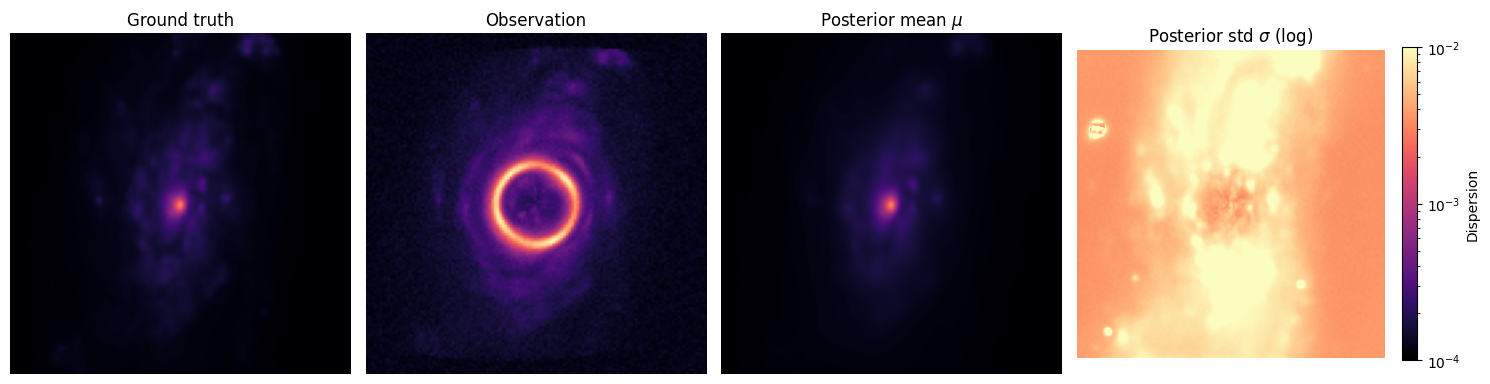

In [8]:
mean = post.mean(0).squeeze(0)   # (256, 256)
std  = post.std(0).squeeze(0)    # (256, 256)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(src,  origin="lower", cmap="magma", vmin=-1, vmax=1); ax[0].set_title("Ground truth")
ax[1].imshow(obs,  origin="lower", cmap="magma");                  ax[1].set_title("Observation")
ax[2].imshow(mean, origin="lower", cmap="magma", vmin=-1, vmax=1); ax[2].set_title(r"Posterior mean $\mu$")
im = ax[3].imshow(std, origin="lower", cmap="magma", norm=LogNorm(vmin=1e-4, vmax=1e-2))
ax[3].set_title(r"Posterior std $\sigma$ (log)")
fig.colorbar(im, ax=ax[3], fraction=0.046, label="Dispersion")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Access individual draws

Each of the 160 samples is `post[i, 0]` (a 256×256 tensor). Use `.numpy()` for arrays.

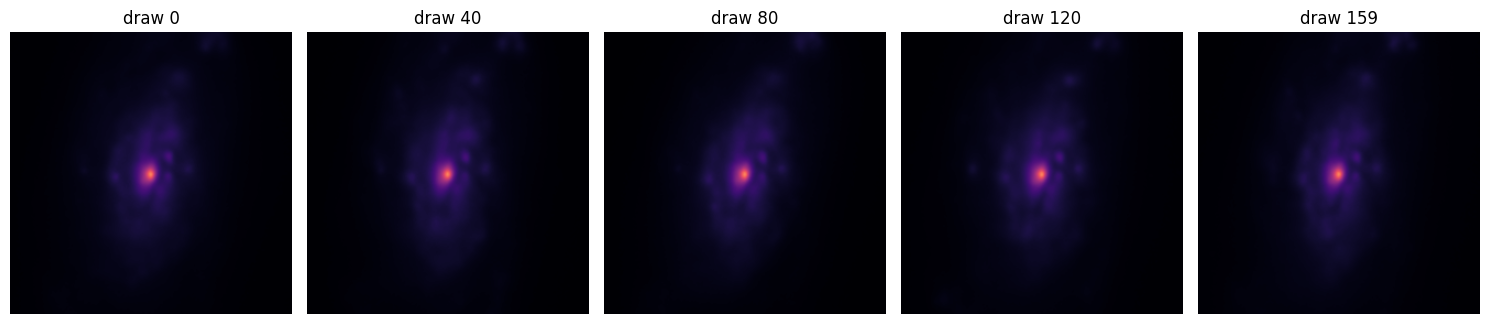

In [9]:
fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for k, i in enumerate([0, 40, 80, 120, 159]):
    ax[k].imshow(post[i, 0], origin="lower", cmap="magma", vmin=-1, vmax=1)
    ax[k].set_title(f"draw {i}"); ax[k].axis("off")
plt.tight_layout(); plt.show()